# META: comparativa de tres formas de gestionar el SHORT mejorado

Este cuaderno compara las mismas entradas LONG/SHORT y modifica únicamente la gestión del SHORT:

1. **Salida RSI (actual):** cierra el 100 % cuando el RSI baja de 50.
2. **Salida parcial + ATR:** cierra el 50 % con RSI < 50 y mantiene el resto con un trailing stop de 2 ATR.
3. **Salida RSI + reentrada:** cierra con RSI < 50 y permite un segundo SHORT si hay rebote sobre EMA10 y después una nueva ruptura bajista de 10 sesiones bajo SMA50.

Todas las señales se calculan al cierre y se ejecutan en la apertura siguiente. El ranking pondera rentabilidad (60 %), menor drawdown (25 %) y aciertos (15 %) en las seis ventanas. Solo se grafica la ganadora a 9 meses.

In [7]:
# Si falta alguna librería, ejecutar una vez:
# %pip install -q yfinance python-dateutil matplotlib pandas numpy

import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import yfinance as yf
from dateutil.relativedelta import relativedelta

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', None)

TICKER = 'META'
CAPITAL_INICIAL = 10_000
VENTANAS = [3, 6, 9, 12, 15, 18]
STOP_LONG = 0.07
STOP_SHORT = 0.07
PERIODO_RUPTURA = 20
MULTIPLICADOR_VOLUMEN = 1.00
PORCENTAJE_SALIDA_PARCIAL = 0.50
MULTIPLICADOR_ATR = 2.0
DIAS_REENTRADA = 20

ESTRATEGIAS = {
    'Salida RSI actual': 'base',
    'Salida parcial 50% + trailing 2 ATR': 'parcial_atr',
    'Salida RSI + reentrada tras rebote': 'reentrada',
}

datos = yf.download(TICKER, period='5y', interval='1d', auto_adjust=True, progress=False)
if datos.empty:
    raise RuntimeError(f'No se pudieron descargar datos de {TICKER}.')
if isinstance(datos.columns, pd.MultiIndex):
    datos.columns = datos.columns.get_level_values(0)
datos = datos[['Open', 'High', 'Low', 'Close', 'Volume']].dropna().copy()
print(f'{TICKER}: {datos.index.min().date()} -> {datos.index.max().date()} | {len(datos)} sesiones')

META: 2021-08-23 -> 2026-08-21 | 1255 sesiones


In [8]:
def rsi_wilder(serie, periodo=14):
    delta = serie.diff()
    ganancias = delta.clip(lower=0)
    perdidas = -delta.clip(upper=0)
    mg = ganancias.ewm(alpha=1 / periodo, adjust=False).mean()
    mp = perdidas.ewm(alpha=1 / periodo, adjust=False).mean()
    return 100 - 100 / (1 + mg / mp)

def preparar_indicadores(df):
    d = df.copy()
    d['RSI'] = rsi_wilder(d['Close'])
    d['BB_MIDDLE'] = d['Close'].rolling(20).mean()
    desv = d['Close'].rolling(20).std()
    d['BB_UPPER'] = d['BB_MIDDLE'] + 2 * desv
    d['BB_LOWER'] = d['BB_MIDDLE'] - 2 * desv
    d['EMA10'] = d['Close'].ewm(span=10, adjust=False).mean()
    d['SMA50'] = d['Close'].rolling(50).mean()
    cierre_previo = d['Close'].shift(1)
    tr = pd.concat([
        d['High'] - d['Low'],
        (d['High'] - cierre_previo).abs(),
        (d['Low'] - cierre_previo).abs(),
    ], axis=1).max(axis=1)
    d['ATR14'] = tr.ewm(alpha=1 / 14, adjust=False).mean()
    d['MINIMO_20_PREV'] = d['Low'].rolling(PERIODO_RUPTURA).min().shift(1)
    d['VOL_20_PREV'] = d['Volume'].rolling(PERIODO_RUPTURA).mean().shift(1)
    d['MINIMO_10_PREV'] = d['Low'].rolling(10).min().shift(1)
    d['LONG_ENTRY'] = (d['RSI'] < 30) & (d['Close'] <= d['BB_LOWER'])
    d['LONG_EXIT'] = (d['RSI'] >= 65) | (d['Close'] >= d['BB_MIDDLE'])
    d['SHORT_RSI'] = d['RSI'] > 70
    d['SHORT_RUPTURA'] = (d['Close'] < d['MINIMO_20_PREV']) & (d['Volume'] > d['VOL_20_PREV'] * MULTIPLICADOR_VOLUMEN)
    d['SHORT_ENTRY'] = d['SHORT_RSI'] | d['SHORT_RUPTURA']
    d['SHORT_EXIT'] = d['RSI'] < 50
    d['REENTRY_BREAK'] = (d['Close'] < d['MINIMO_10_PREV']) & (d['Close'] < d['SMA50'])
    return d

datos = preparar_indicadores(datos)

def calcular_buy_hold(df):
    return (float(df['Close'].iloc[-1]) / float(df['Close'].iloc[0]) - 1) * 100

In [9]:
def ejecutar_backtest(df, variante, capital_inicial=CAPITAL_INICIAL):
    d = df.copy()
    capital = float(capital_inicial)
    posicion = None
    precio_entrada = fecha_entrada = sistema = None
    capital_inicio_trade = None
    peso_abierto, retorno_realizado = 0.0, 0.0
    minimo_desde_entrada, trailing = np.inf, np.inf
    parcial_hecha = False
    operaciones, tramos, equity = [], [], []
    reentrada_hasta = None
    rebote_detectado = False

    def rent_short(precio):
        return (precio_entrada - precio) / precio_entrada

    def cerrar_trade(fecha, precio, motivo, peso=1.0):
        nonlocal capital, posicion, precio_entrada, fecha_entrada, sistema
        nonlocal peso_abierto, retorno_realizado, parcial_hecha
        nonlocal minimo_desde_entrada, trailing, capital_inicio_trade
        retorno = ((precio - precio_entrada) / precio_entrada if posicion == 'LONG' else rent_short(precio))
        retorno_realizado += peso * retorno
        peso_abierto -= peso
        tramos.append({'Tipo': posicion, 'Sistema entrada': sistema, 'Entrada': fecha_entrada,
                       'Precio entrada': precio_entrada, 'Salida': fecha, 'Precio salida': precio,
                       'Peso %': peso * 100, 'Rentabilidad tramo %': retorno * 100, 'Motivo': motivo})
        if peso_abierto <= 1e-12:
            capital = capital_inicio_trade * (1 + retorno_realizado)
            operaciones.append({'Tipo': posicion, 'Sistema entrada': sistema, 'Entrada': fecha_entrada,
                'Precio entrada': precio_entrada, 'Salida': fecha, 'Precio salida': precio,
                'Rentabilidad %': retorno_realizado * 100, 'Motivo': motivo})
            posicion = precio_entrada = fecha_entrada = sistema = capital_inicio_trade = None
            peso_abierto, retorno_realizado = 0.0, 0.0
            minimo_desde_entrada, trailing, parcial_hecha = np.inf, np.inf, False

    for i in range(1, len(d)):
        fecha, fila, senal = d.index[i], d.iloc[i], d.iloc[i - 1]
        apertura, maximo, minimo, cierre = map(float, [fila['Open'], fila['High'], fila['Low'], fila['Close']])

        if variante == 'reentrada' and reentrada_hasta is not None:
            if d.index[i - 1] > reentrada_hasta:
                reentrada_hasta, rebote_detectado = None, False
            elif bool(senal['Close'] > senal['EMA10']):
                rebote_detectado = True

        if posicion is None:
            entrada_tipo = None
            if bool(senal['LONG_ENTRY']):
                posicion, sistema = 'LONG', 'RSI + BOLLINGER'
            elif variante == 'reentrada' and rebote_detectado and bool(senal['REENTRY_BREAK']):
                posicion, sistema, entrada_tipo = 'SHORT', 'REENTRADA', 'reentrada'
            elif bool(senal['SHORT_ENTRY']):
                posicion = 'SHORT'
                sistema = 'RUPTURA' if bool(senal['SHORT_RUPTURA']) else 'RSI > 70'
            if posicion is not None:
                precio_entrada, fecha_entrada = apertura, fecha
                capital_inicio_trade, peso_abierto, retorno_realizado = capital, 1.0, 0.0
                minimo_desde_entrada = apertura
                trailing = apertura * (1 + STOP_SHORT)
                if entrada_tipo == 'reentrada':
                    reentrada_hasta, rebote_detectado = None, False

        elif posicion == 'LONG':
            stop = precio_entrada * (1 - STOP_LONG)
            if minimo <= stop:
                cerrar_trade(fecha, apertura if apertura < stop else stop, 'STOP LOSS LONG', peso_abierto)
            elif bool(senal['LONG_EXIT']):
                cerrar_trade(fecha, apertura, 'SEÑAL SALIDA LONG', peso_abierto)

        elif posicion == 'SHORT':
            stop_inicial = precio_entrada * (1 + STOP_SHORT)
            stop_activo = min(stop_inicial, trailing) if variante == 'parcial_atr' and parcial_hecha else stop_inicial
            if maximo >= stop_activo:
                cerrar_trade(fecha, apertura if apertura > stop_activo else stop_activo, 'STOP/TRAILING SHORT', peso_abierto)
            elif bool(senal['SHORT_EXIT']):
                if variante == 'parcial_atr' and not parcial_hecha:
                    cerrar_trade(fecha, apertura, 'SALIDA PARCIAL RSI < 50', PORCENTAJE_SALIDA_PARCIAL)
                    parcial_hecha = True
                elif variante != 'parcial_atr':
                    cerrar_trade(fecha, apertura, 'SEÑAL SALIDA SHORT', peso_abierto)
                    if variante == 'reentrada':
                        reentrada_hasta = fecha + pd.Timedelta(days=DIAS_REENTRADA * 2)
                        rebote_detectado = False
            if posicion == 'SHORT' and variante == 'parcial_atr':
                minimo_desde_entrada = min(minimo_desde_entrada, cierre)
                if parcial_hecha and pd.notna(fila['ATR14']):
                    trailing = min(trailing, minimo_desde_entrada + MULTIPLICADOR_ATR * float(fila['ATR14']))

        if posicion == 'LONG':
            valor = capital_inicio_trade * (1 + (cierre - precio_entrada) / precio_entrada)
        elif posicion == 'SHORT':
            valor = capital_inicio_trade * (1 + retorno_realizado + peso_abierto * rent_short(cierre))
        else:
            valor = capital
        equity.append({'Fecha': fecha, 'Equity': valor})

    if posicion is not None:
        cerrar_trade(d.index[-1], float(d['Close'].iloc[-1]), 'FIN DEL PERIODO', peso_abierto)
        if equity:
            equity[-1]['Equity'] = capital

    eq = pd.DataFrame(equity).set_index('Fecha') if equity else pd.DataFrame(columns=['Equity'])
    dd = ((eq['Equity'] / eq['Equity'].cummax()) - 1).min() * 100 if not eq.empty else 0.0
    aciertos = 100 * sum(x['Rentabilidad %'] > 0 for x in operaciones) / len(operaciones) if operaciones else 0.0
    return {'Capital final': capital, 'Rentabilidad %': (capital / capital_inicial - 1) * 100,
            'Drawdown máximo %': dd, 'Operaciones': len(operaciones), '% Aciertos': aciertos,
            'Operaciones detalle': operaciones, 'Tramos': tramos, 'Equity': eq}


In [10]:
resultados, filas = {}, []
fecha_final = datos.index[-1]
for nombre, variante in ESTRATEGIAS.items():
    resultados[nombre] = {}
    for meses in VENTANAS:
        periodo = datos.loc[datos.index >= fecha_final - relativedelta(months=meses)].copy()
        if len(periodo) < 50:
            continue
        r = ejecutar_backtest(periodo, variante)
        bh = calcular_buy_hold(periodo)
        resultados[nombre][meses] = {'datos': periodo, 'resultado': r}
        filas.append({'Estrategia': nombre, 'Ventana meses': meses, 'Capital final': r['Capital final'],
            'Rentabilidad %': r['Rentabilidad %'], 'Buy & Hold %': bh,
            'Diferencia vs B&H %': r['Rentabilidad %'] - bh, 'Drawdown máximo %': r['Drawdown máximo %'],
            'Operaciones': r['Operaciones'], '% Aciertos': r['% Aciertos']})

df_resultados = pd.DataFrame(filas)
print('RESULTADOS DE LAS TRES VARIANTES EN TODAS LAS VENTANAS')
display(df_resultados.style.format({
    'Capital final': '${:,.2f}', 'Rentabilidad %': '{:+.2f}%', 'Buy & Hold %': '{:+.2f}%',
    'Diferencia vs B&H %': '{:+.2f}%', 'Drawdown máximo %': '{:+.2f}%', '% Aciertos': '{:.1f}%'}))

RESULTADOS DE LAS TRES VARIANTES EN TODAS LAS VENTANAS


,Estrategia,Ventana meses,Capital final,Rentabilidad %,Buy & Hold %,Diferencia vs B&H %,Drawdown máximo %,Operaciones,% Aciertos
0,Salida RSI actual,3,"$9,178.46",-8.22%,-9.38%,+1.16%,-9.16%,2,0.0%
1,Salida RSI actual,6,"$10,682.19",+6.82%,-13.55%,+20.38%,-9.16%,5,40.0%
2,Salida RSI actual,9,"$10,951.18",+9.51%,-7.22%,+16.73%,-9.16%,8,50.0%
3,Salida RSI actual,12,"$10,361.99",+3.62%,-25.35%,+28.97%,-13.49%,11,45.5%
4,Salida RSI actual,15,"$9,982.60",-0.17%,-13.12%,+12.95%,-15.22%,13,46.2%
5,Salida RSI actual,18,"$9,923.21",-0.77%,-19.15%,+18.39%,-22.73%,18,44.4%
6,Salida parcial 50% + trailing 2 ATR,3,"$8,950.93",-10.49%,-9.38%,-1.11%,-12.18%,2,0.0%
7,Salida parcial 50% + trailing 2 ATR,6,"$9,452.50",-5.48%,-13.55%,+8.08%,-13.06%,3,33.3%
8,Salida parcial 50% + trailing 2 ATR,9,"$10,346.32",+3.46%,-7.22%,+10.69%,-12.55%,4,50.0%
9,Salida parcial 50% + trailing 2 ATR,12,"$10,671.25",+6.71%,-25.35%,+32.07%,-12.55%,6,50.0%


In [11]:
# Ranking por rangos dentro de cada ventana: menor puntuación = mejor.
ranked = df_resultados.copy()
ranked['Rango rentabilidad'] = ranked.groupby('Ventana meses')['Rentabilidad %'].rank(ascending=False, method='average')
ranked['Rango drawdown'] = ranked.groupby('Ventana meses')['Drawdown máximo %'].rank(ascending=False, method='average')
ranked['Rango aciertos'] = ranked.groupby('Ventana meses')['% Aciertos'].rank(ascending=False, method='average')
ranked['Puntuación'] = 0.60 * ranked['Rango rentabilidad'] + 0.25 * ranked['Rango drawdown'] + 0.15 * ranked['Rango aciertos']

ranking = ranked.groupby('Estrategia').agg(
    **{'Puntuación final': ('Puntuación', 'mean'), 'Rentabilidad media %': ('Rentabilidad %', 'mean'),
       'Rentabilidad mínima %': ('Rentabilidad %', 'min'), 'Drawdown medio %': ('Drawdown máximo %', 'mean'),
       'Aciertos medios %': ('% Aciertos', 'mean'), 'Ventanas positivas': ('Rentabilidad %', lambda s: int((s > 0).sum()))}
).sort_values(['Puntuación final', 'Rentabilidad media %'], ascending=[True, False]).reset_index()
ranking.insert(0, 'Puesto', range(1, len(ranking) + 1))
ganadora = ranking.iloc[0]['Estrategia']

print('RANKING GENERAL')
display(ranking.style.format({'Puntuación final': '{:.3f}', 'Rentabilidad media %': '{:+.2f}%',
    'Rentabilidad mínima %': '{:+.2f}%', 'Drawdown medio %': '{:+.2f}%', 'Aciertos medios %': '{:.1f}%'}))
print(f'GANADORA: {ganadora}')
for _, x in ranking.iterrows():
    explicacion = (f"#{int(x['Puesto'])} {x['Estrategia']}: rentabilidad media {x['Rentabilidad media %']:+.2f}%, "
                   f"{int(x['Ventanas positivas'])}/6 ventanas positivas, drawdown medio {x['Drawdown medio %']:.2f}% "
                   f"y aciertos medios {x['Aciertos medios %']:.1f}%.")
    print(explicacion)
print('La ganadora es la que obtiene la menor puntuación ponderada y, por tanto, el mejor equilibrio entre rentabilidad, riesgo y aciertos en todas las ventanas.')

RANKING GENERAL


,Puesto,Estrategia,Puntuación final,Rentabilidad media %,Rentabilidad mínima %,Drawdown medio %,Aciertos medios %,Ventanas positivas
0,1,Salida RSI actual,1.613,+1.80%,-8.22%,-13.15%,37.7%,3
1,2,Salida RSI + reentrada tras rebote,2.112,+1.00%,-10.44%,-14.26%,47.1%,3
2,3,Salida parcial 50% + trailing 2 ATR,2.275,-0.51%,-10.49%,-13.58%,36.0%,3


GANADORA: Salida RSI actual
#1 Salida RSI actual: rentabilidad media +1.80%, 3/6 ventanas positivas, drawdown medio -13.15% y aciertos medios 37.7%.
#2 Salida RSI + reentrada tras rebote: rentabilidad media +1.00%, 3/6 ventanas positivas, drawdown medio -14.26% y aciertos medios 47.1%.
#3 Salida parcial 50% + trailing 2 ATR: rentabilidad media -0.51%, 3/6 ventanas positivas, drawdown medio -13.58% y aciertos medios 36.0%.
La ganadora es la que obtiene la menor puntuación ponderada y, por tanto, el mejor equilibrio entre rentabilidad, riesgo y aciertos en todas las ventanas.


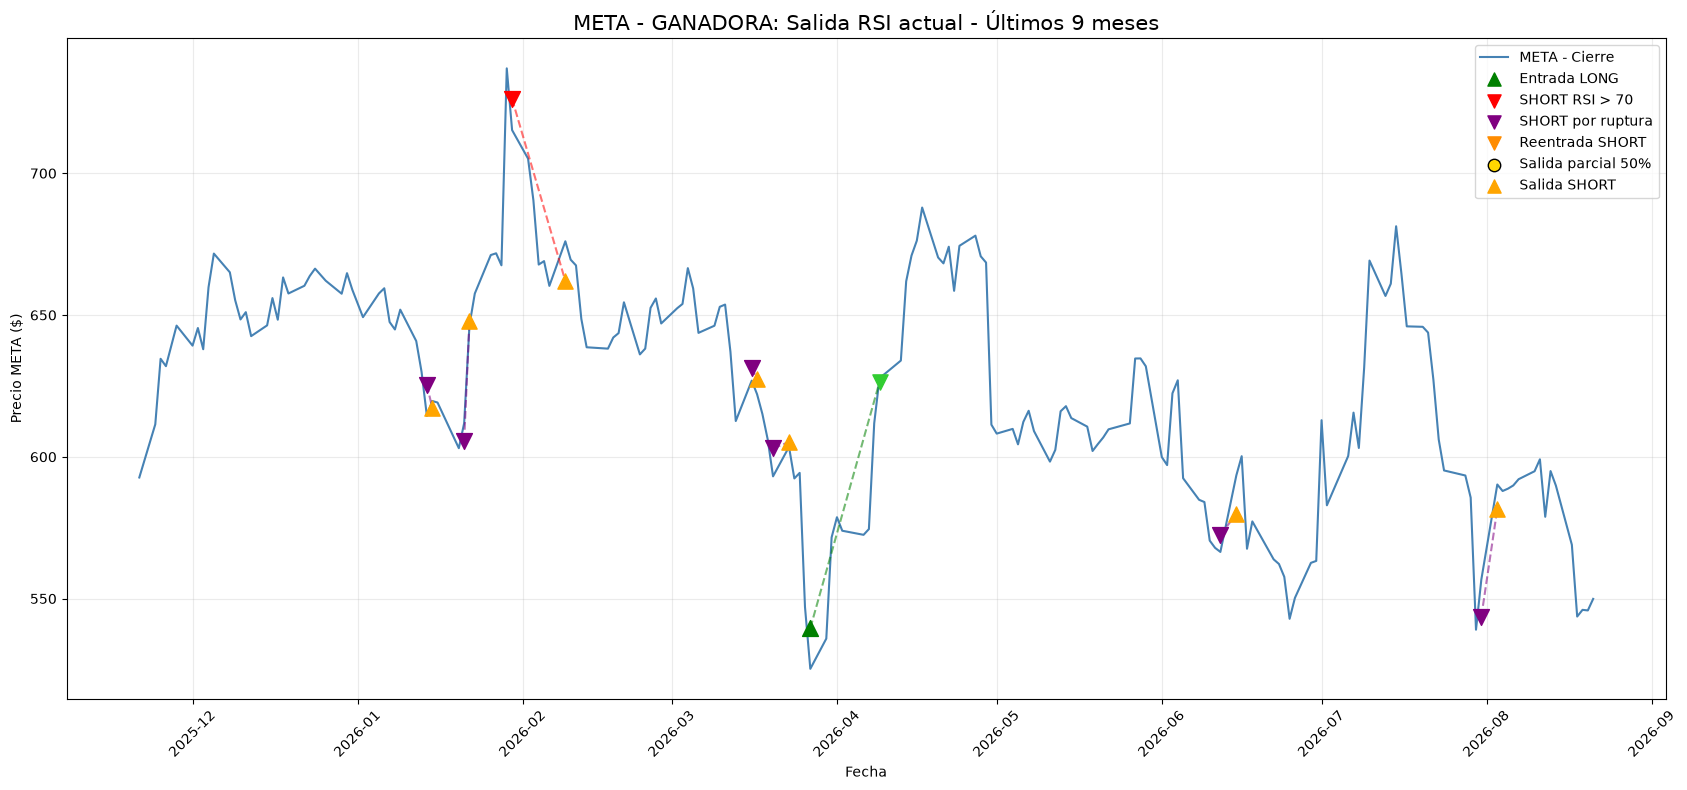

OPERACIONES DE LA GANADORA A 9 MESES


,Tipo,Sistema entrada,Entrada,Precio entrada,Salida,Precio salida,Rentabilidad %,Motivo
0,SHORT,RUPTURA,2026-01-14 00:00:00,$625.38,2026-01-15 00:00:00,$617.38,+1.28%,SEÑAL SALIDA SHORT
1,SHORT,RUPTURA,2026-01-21 00:00:00,$605.66,2026-01-22 00:00:00,$648.06,-7.00%,STOP/TRAILING SHORT
2,SHORT,RSI > 70,2026-01-30 00:00:00,$726.20,2026-02-09 00:00:00,$662.00,+8.84%,SEÑAL SALIDA SHORT
3,SHORT,RUPTURA,2026-03-16 00:00:00,$631.41,2026-03-17 00:00:00,$627.41,+0.63%,SEÑAL SALIDA SHORT
4,SHORT,RUPTURA,2026-03-20 00:00:00,$602.97,2026-03-23 00:00:00,$605.23,-0.37%,SEÑAL SALIDA SHORT
5,LONG,RSI + BOLLINGER,2026-03-27 00:00:00,$539.60,2026-04-09 00:00:00,$626.39,+16.08%,SEÑAL SALIDA LONG
6,SHORT,RUPTURA,2026-06-12 00:00:00,$572.42,2026-06-15 00:00:00,$579.90,-1.31%,SEÑAL SALIDA SHORT
7,SHORT,RUPTURA,2026-07-31 00:00:00,$543.60,2026-08-03 00:00:00,$581.65,-7.00%,STOP/TRAILING SHORT


In [13]:
# ÚNICO GRÁFICO: estrategia ganadora, ventana de 9 meses
if 9 not in resultados[ganadora]:
    raise RuntimeError('No hay suficientes datos para construir la ventana de 9 meses.')
pack = resultados[ganadora][9]
periodo, r = pack['datos'], pack['resultado']
fig, ax = plt.subplots(figsize=(17, 8))
ax.plot(periodo.index, periodo['Close'], lw=1.5, color='steelblue', label='META - Cierre')
for op in r['Operaciones detalle']:
    if op['Tipo'] == 'LONG':
        color, marcador, etiqueta = 'green', '^', 'Entrada LONG'
    elif op['Sistema entrada'] == 'RUPTURA':
        color, marcador, etiqueta = 'purple', 'v', 'SHORT por ruptura'
    elif op['Sistema entrada'] == 'REENTRADA':
        color, marcador, etiqueta = 'darkorange', 'v', 'Reentrada SHORT'
    else:
        color, marcador, etiqueta = 'red', 'v', 'SHORT RSI > 70'
    ax.scatter(op['Entrada'], op['Precio entrada'], color=color, marker=marcador, s=130, zorder=5)
    ax.scatter(op['Salida'], op['Precio salida'], color='orange' if op['Tipo'] == 'SHORT' else 'limegreen',
               marker='^' if op['Tipo'] == 'SHORT' else 'v', s=120, zorder=5)
    ax.plot([op['Entrada'], op['Salida']], [op['Precio entrada'], op['Precio salida']], ls='--', color=color, alpha=.55)
# Marcamos también la salida parcial, si la ganadora la utiliza.
for tramo in r['Tramos']:
    if tramo['Motivo'] == 'SALIDA PARCIAL RSI < 50':
        ax.scatter(tramo['Salida'], tramo['Precio salida'], color='gold', edgecolor='black', marker='o', s=105, zorder=7)
ax.scatter([], [], color='green', marker='^', s=90, label='Entrada LONG')
ax.scatter([], [], color='red', marker='v', s=90, label='SHORT RSI > 70')
ax.scatter([], [], color='purple', marker='v', s=90, label='SHORT por ruptura')
ax.scatter([], [], color='darkorange', marker='v', s=90, label='Reentrada SHORT')
ax.scatter([], [], color='gold', edgecolor='black', marker='o', s=80, label='Salida parcial 50%')
ax.scatter([], [], color='orange', marker='^', s=90, label='Salida SHORT')
ax.set_title(f'META - GANADORA: {ganadora} - Últimos 9 meses', fontsize=15)
ax.set_xlabel('Fecha'); ax.set_ylabel('Precio META ($)'); ax.grid(alpha=.25); ax.legend(loc='best')
plt.xticks(rotation=45); plt.tight_layout(); plt.show()

print('OPERACIONES DE LA GANADORA A 9 MESES')
display(pd.DataFrame(r['Operaciones detalle']).style.format({
    'Precio entrada': '${:,.2f}', 'Precio salida': '${:,.2f}', 'Rentabilidad %': '{:+.2f}%'}))